In [ ]:
import pandas as pd
train_url = "https://raw.githubusercontent.com/17m301/BioFuel_YieldPrediction/main/Datasets/Train/Trainset_dataset1.xlsx"
test_yield_url = "https://raw.githubusercontent.com/17m301/BioFuel_YieldPrediction/refs/heads/main/Datasets/Test/Testset_dataset1%20(1).csv"
test_url = "https://raw.githubusercontent.com/17m301/BioFuel_YieldPrediction/main/Datasets/Test/Testset_feature_dataset1.xlsx"

df_train = pd.read_excel(train_url)
df_test = pd.read_excel(test_url)
df_test_feature = pd.read_csv(test_yield_url)
df_train.info()
#df_train.head()
df_test.info()
df_test_feature.info()

Understanding the data

In [59]:
df_train.shape #how big is the data?
df_train.describe()# datatype of each column




,Ash(wt%),FixedCarbon(wt%),Volatiles(wt%),C(wt%),H(wt%),O(wt%),N(wt%),H/C,Cellulose(wt%),Hemicellulose(wt%),Lignin(wt%),T(^C),HeatingRate(^C/min),ParticleSize(mm),FlowRate-Nitrogen(ml/min),yield(wt%)
count,845.000000,845.000000,845.000000,845.000000,845.000000,845.000000,845.000000,845.000000,845.000000,845.000000,845.000000,845.000000,845.000000,845.000000,845.000000,845.000000
mean,5.537343,16.121636,78.341021,49.267011,6.476477,40.641392,2.952136,0.121893,33.545116,25.686631,25.167018,514.674556,65.073373,0.812234,125.177515,40.478817
std,3.669400,8.112269,9.475040,6.705218,1.152200,8.575944,2.544919,0.041218,11.368967,9.783094,10.906968,90.715530,112.020190,0.526874,242.063168,9.902880
min,0.278552,0.107181,10.855927,19.490000,2.410000,10.490000,0.170000,0.100000,5.750000,3.400000,0.800000,300.000000,5.000000,0.100000,0.000000,11.000000
25%,2.437648,11.983033,75.807672,44.820000,5.890000,34.530000,0.920000,0.100000,26.933333,19.066667,17.000000,450.000000,7.000000,0.450000,0.000000,33.000000
50%,5.061689,15.409846,78.747204,47.400000,6.230000,41.630000,2.050000,0.100000,32.060000,24.136667,27.000000,500.000000,20.000000,0.650000,100.000000,40.300000
75%,7.286460,17.114094,82.526000,52.900000,6.735700,48.280000,4.400000,0.100000,42.200000,31.700000,34.200000,550.000000,50.000000,1.000000,100.000000,47.800000
max,40.084388,78.545821,95.984215,79.770000,10.590000,54.120000,9.290000,0.200000,60.270000,51.340000,50.400000,900.000000,800.000000,3.200000,2000.000000,77.200000


Find out Total Missing values of each column

In [ ]:
print(df_train.isnull().sum())
print()
print(df_test.isnull().sum())

In [69]:
print(df_train.duplicated().sum())
#df_train[df_train.duplicated()] # Print the duplicates
df_train.drop_duplicates(inplace=True)
print(df_train.duplicated().sum())

0
0


In [ ]:
!pip install ydata-profiling
from ydata_profiling import ProfileReport
prof=ProfileReport(df_train)
prof.to_file(output_file='output_train.html')
prof=ProfileReport(df_test)
prof.to_file(output_file='output_test.html')
prof=ProfileReport(df_test_feature)
prof.to_file(output_file='output_test_feature.html')

EDA

Univariant Analysis


In [ ]:
import matplotlib.pyplot as plt
plt.hist(df_train['yield(wt%)'])

# Handling Missing Data

In [70]:
#Using KNN Imputers
from sklearn.impute import KNNImputer
imputer=KNNImputer(n_neighbors=3)
x_train=df_train.drop(columns=['yield(wt%)'])
y_train=df_train['yield(wt%)']
x_train=pd.DataFrame(imputer.fit_transform(x_train),columns=x_train.columns)
df_test=pd.DataFrame(imputer.fit_transform(df_test),columns=df_test.columns)
#df_test_feature=pd.DataFrame(imputer.fit_transform(df_test_feature),columns=df_test_feature.columns)

In [71]:
print(x_train.isnull().sum())
print()
print(df_test.isnull().sum())

Ash(wt%)                     0
FixedCarbon(wt%)             0
Volatiles(wt%)               0
C(wt%)                       0
H(wt%)                       0
O(wt%)                       0
N(wt%)                       0
H/C                          0
Cellulose(wt%)               0
Hemicellulose(wt%)           0
Lignin(wt%)                  0
T(^C)                        0
HeatingRate(^C/min)          0
ParticleSize(mm)             0
FlowRate-Nitrogen(ml/min)    0
dtype: int64

Ash(wt%)                     0
FixedCarbon(wt%)             0
Volatiles(wt%)               0
C(wt%)                       0
H(wt%)                       0
O(wt%)                       0
N(wt%)                       0
H/C                          0
Cellulose(wt%)               0
Hemicellulose(wt%)           0
Lignin(wt%)                  0
T(^C)                        0
HeatingRate(^C/min)          0
ParticleSize(mm)             0
FlowRate-Nitrogen(ml/min)    0
dtype: int64


# Outlier Detection

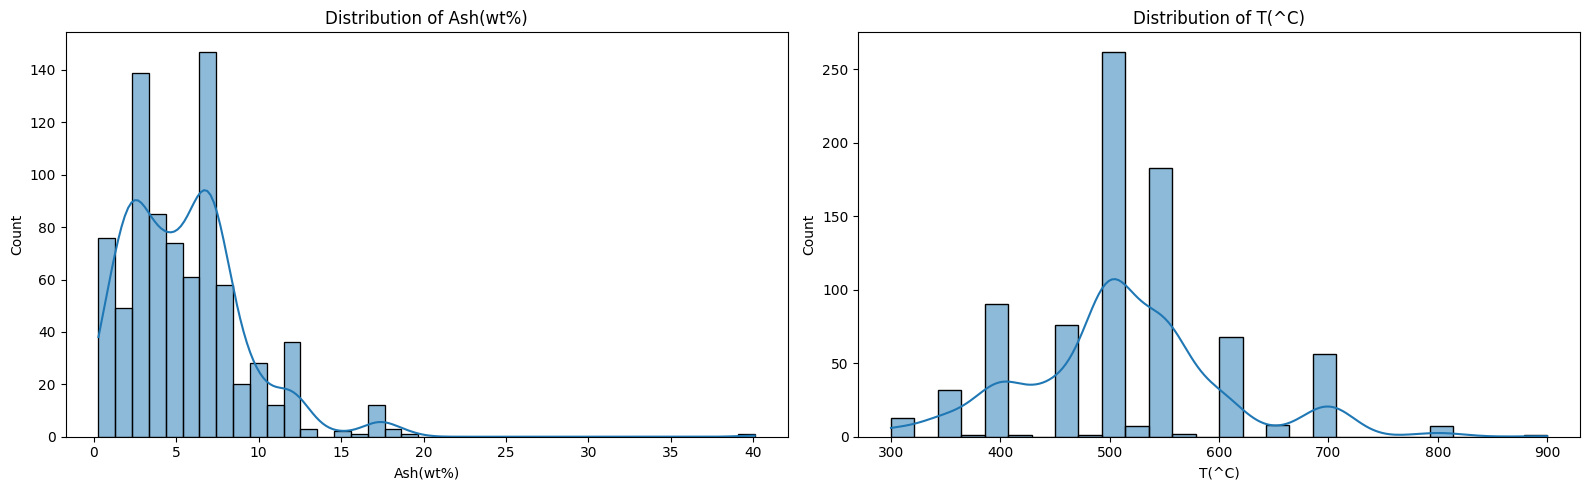

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size for better visibility
plt.figure(figsize=(16, 5))

# Subplot 1
plt.subplot(1, 2, 1)
sns.histplot(x_train['Ash(wt%)'], kde=True)
plt.title('Distribution of Ash(wt%)')

# Subplot 2
plt.subplot(1, 2, 2)
sns.histplot(x_train['T(^C)'], kde=True)
plt.title('Distribution of T(^C)')

plt.tight_layout()
plt.show()

In [73]:
#Normal distribution, Skewed distribution (for skewed data)
#Zscore , IQR based filtering, percentile, Winsorization

#Right Skewed
print(x_train['Ash(wt%)'].skew())
print(x_train['C(wt%)'].skew())
print(x_train['Cellulose(wt%)'].skew())
print(x_train['FixedCarbon(wt%)'].skew())

1.7802335646613963
1.1474474168753819
0.08166562906054953
4.8749316405050225


Boxplot of each features

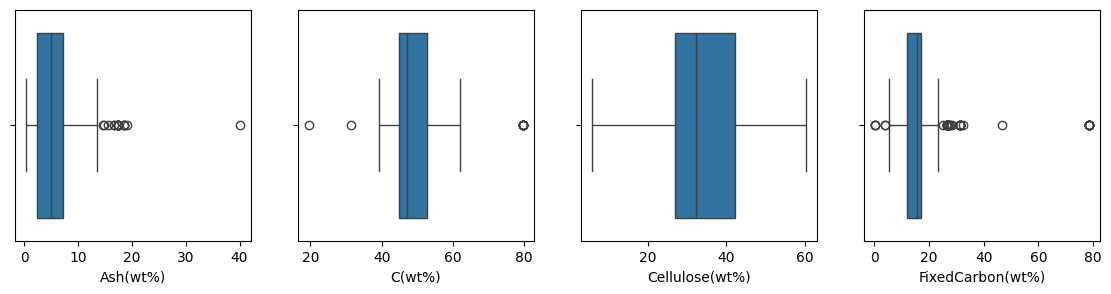

In [74]:
plt.figure(figsize=(14, 3))

plt.subplot(1,4,1)
sns.boxplot(x=x_train['Ash(wt%)'])
plt.subplot(1,4,2)
sns.boxplot(x=x_train['C(wt%)'])
plt.subplot(1,4,3)
sns.boxplot(x=x_train['Cellulose(wt%)'])
plt.subplot(1,4,4)
sns.boxplot(x=x_train['FixedCarbon(wt%)'])
plt.show()


Finding the IQR for each feature


In [75]:
from numpy import percentile

# Dictionary to store outlier counts
outlier_counts = {}
value_limits={}

for col in x_train.columns:
    q1 = x_train[col].quantile(0.25)
    q3 = x_train[col].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    value_limits[col]=[lower_limit,upper_limit]

    # Count outliers
    num_outliers = x_train[(x_train[col] < lower_limit) | (x_train[col] > upper_limit)].shape[0]
    outlier_counts[col] = num_outliers

# Convert to Series for better display
outlier_summary = pd.Series(outlier_counts)
print("Total Outliers per Feature:")
print(outlier_summary)
print()
print("Value Limits per Feature:")
print(value_limits)

Total Outliers per Feature:
Ash(wt%)                      20
FixedCarbon(wt%)              54
Volatiles(wt%)                47
C(wt%)                        11
H(wt%)                       117
O(wt%)                         9
N(wt%)                         0
H/C                          183
Cellulose(wt%)                 0
Hemicellulose(wt%)             1
Lignin(wt%)                    0
T(^C)                          8
HeatingRate(^C/min)          114
ParticleSize(mm)              37
FlowRate-Nitrogen(ml/min)     73
dtype: int64

Value Limits per Feature:
{'Ash(wt%)': [np.float64(-4.9009886233462945), np.float64(14.598929284193265)], 'FixedCarbon(wt%)': [np.float64(4.286441244920252), np.float64(24.810685588618245)], 'Volatiles(wt%)': [np.float64(65.64773596082011), np.float64(92.65308473929741)], 'C(wt%)': [np.float64(32.7), np.float64(65.02)], 'H(wt%)': [np.float64(4.621449999999999), np.float64(8.004249999999999)], 'O(wt%)': [np.float64(12.205000000000002), np.float64(69.925)], 'N(

Capping

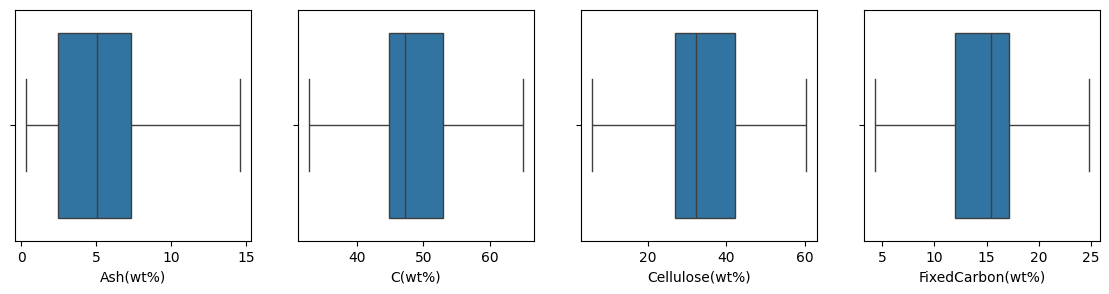

In [76]:
x_train_capped = x_train.copy()

# Apply capping using the limits stored in value_limits
for col in x_train_capped.columns:
    lower, upper = value_limits[col]
    x_train_capped[col] = x_train_capped[col].clip(lower=lower, upper=upper)

plt.figure(figsize=(14, 3))

plt.subplot(1,4,1)
sns.boxplot(x=x_train_capped['Ash(wt%)'])
plt.subplot(1,4,2)
sns.boxplot(x=x_train_capped['C(wt%)'])
plt.subplot(1,4,3)
sns.boxplot(x=x_train_capped['Cellulose(wt%)'])
plt.subplot(1,4,4)
sns.boxplot(x=x_train_capped['FixedCarbon(wt%)'])
plt.show()

# Feature Scaling
Standard Scaler

In [8]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
#fitting the scaler to the training set to learn the parameter
scaler.fit(df_train)
#Now transform the train set
df_train_scaled=scaler.transform(df_train)

#above step will return numpy array so we need to transform this to DataFrame
df_train_scaled=pd.DataFrame(df_train_scaled,columns=df_train.columns)
df_train_scaled.describe()

#Standardization used for K Means, KNN, ANN, GD and PCA
#algo which uses distance to measure similarity which will affect when the data is having huge range difference, so we need to regularize

,Ash(wt%),FixedCarbon(wt%),Volatiles(wt%),C(wt%),H(wt%),O(wt%),N(wt%),H/C,Cellulose(wt%),Hemicellulose(wt%),Lignin(wt%),T(^C),HeatingRate(^C/min),ParticleSize(mm),FlowRate-Nitrogen(ml/min),yield(wt%)
count,7.470000e+02,7.470000e+02,7.470000e+02,8.450000e+02,8.350000e+02,8.350000e+02,805.000000,8.350000e+02,6.690000e+02,4.830000e+02,5.100000e+02,8.450000e+02,8.450000e+02,8.450000e+02,8.450000e+02,8.450000e+02
mean,-4.755975e-17,-5.707171e-17,5.992529e-16,5.928197e-16,-2.595396e-16,-9.360443e-16,0.000000,-2.637943e-16,-1.327621e-16,3.677757e-17,-3.483053e-17,6.222504e-16,2.522637e-17,1.093143e-16,3.363516e-17,-5.297538e-16
std,1.000670e+00,1.000670e+00,1.000670e+00,1.000592e+00,1.000599e+00,1.000599e+00,1.000622,1.000599e+00,1.000748e+00,1.001037e+00,1.000982e+00,1.000592e+00,1.000592e+00,1.000592e+00,1.000592e+00,1.000592e+00
min,-1.415443e+00,-1.866147e+00,-6.772507e+00,-4.443501e+00,-3.525390e+00,-3.497731e+00,-1.083642,-5.279334e-01,-2.459289e+00,-2.253492e+00,-1.893588e+00,-2.367860e+00,-5.365903e-01,-1.352612e+00,-5.174337e-01,-2.978555e+00
25%,-8.713913e-01,-4.748821e-01,-2.576669e-01,-6.636092e-01,-5.125699e-01,-7.444763e-01,-0.789517,-5.279334e-01,-6.022396e-01,-7.579656e-01,-6.639490e-01,-7.133603e-01,-5.187258e-01,-6.879232e-01,-5.174337e-01,-7.556636e-01
50%,-1.000917e-01,-1.351655e-01,4.063053e-02,-2.786064e-01,-2.182139e-01,1.198367e-01,-0.346369,-5.279334e-01,-1.814816e-01,-1.859267e-01,2.981136e-01,-1.618603e-01,-4.026066e-01,-3.081010e-01,-1.040738e-01,-1.806772e-02
75%,4.403835e-01,1.265332e-01,4.777015e-01,5.421361e-01,2.195974e-01,8.923745e-01,0.575221,-5.279334e-01,7.656568e-01,8.450517e-01,6.436248e-01,3.896396e-01,-1.346391e-01,3.565879e-01,-1.040738e-01,7.397363e-01
max,9.125892e+00,7.324416e+00,1.770428e+00,4.551836e+00,3.556469e+00,1.570814e+00,2.492914,1.894178e+00,2.260820e+00,2.227479e+00,2.401489e+00,4.250139e+00,6.564548e+00,4.534632e+00,7.749766e+00,3.710328e+00


# Effect of StandardScaling

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
ax1.scatter(df_train['FixedCarbon(wt%)'], df_train['yield(wt%)'])
ax1.set_title('Before Scaling')
ax2.scatter(df_train_scaled['FixedCarbon(wt%)'], df_train_scaled['yield(wt%)'])
ax2.set_title('After Scaling')
plt.show()

# Normalization using MinMax Scaling

In [ ]:
#To change a numeric values to use a common scale
#xi-xmin /(xmax-xmin)
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaler.fit(df_train)
df_train_MinMax=scaler.transform(df_train)
df_train_MinMax=pd.DataFrame(df_train,columns=df_train.columns)
df_train_MinMax.describe()



In [ ]:
fig, (ax1, ax2,ax3) = plt.subplots(ncols=3, figsize=(12, 5))
ax1.scatter(df_train['FixedCarbon(wt%)'], df_train['yield(wt%)'])
ax1.set_title('Before Norm/Standardization')
ax2.scatter(df_train_MinMax['FixedCarbon(wt%)'], df_train_MinMax['yield(wt%)'])
ax2.set_title('After Normalization')
ax3.scatter(df_train_scaled['FixedCarbon(wt%)'], df_train_scaled['yield(wt%)'])
ax3.set_title('After Standard Scaling')
plt.show()